In [1]:
%load_ext autoreload
%autoreload 2

# Get parent root directory and add to sys.path
import sys, os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
from src.rocket import Rocket
from src.pos_rocket_vis import *
from LandMPC.nmpc_land import NmpcCtrl
import numpy as np

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir,"rocket.yaml")

# Rocket setup
Ts  = 1/20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
rocket.mass = 1.7 # Do not change!!!

# Visualization setup
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1

In [3]:
sim_time = 10.0 # simulation length in seconds
# x0 = [wx, wy, wz, alpha, beta, gamma, vx, vy, vz, x, y, z]
x0 = np.zeros(12)
x0[5] = np.deg2rad(30) # gamma (roll)
x0[9] = 3.0 # x
x0[10] = 2.0 # y
x0[11] = 10.0 # z

x_ref = np.zeros(12)
x_ref[9] = 1.0
x_ref[10] = 0.0
x_ref[11] = 3.0

xs, us = rocket.trim(x_ref)
print("Linearization around a steady state:")
print("x_ref = ", x_ref)
print("xs = ", xs)
print("us = ", us)

H = 2.0 # horizon time 
nmpc = NmpcCtrl(rocket, H, xs, us)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Linearization around a steady state:
x_ref =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
us =  [ 0.          0.         56.66666667  0.        ]


In [4]:
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol = rocket.simulate_land(nmpc, sim_time, H, x0)

Simulating time 0.00
Simulating time 1.00
Simulating time 2.00
Simulating time 3.00
Simulating time 4.00
Simulating time 5.00
Simulating time 6.00
Simulating time 7.00
Simulating time 8.00
Simulating time 9.00


AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=199, step=2), IntSlider(value=0…

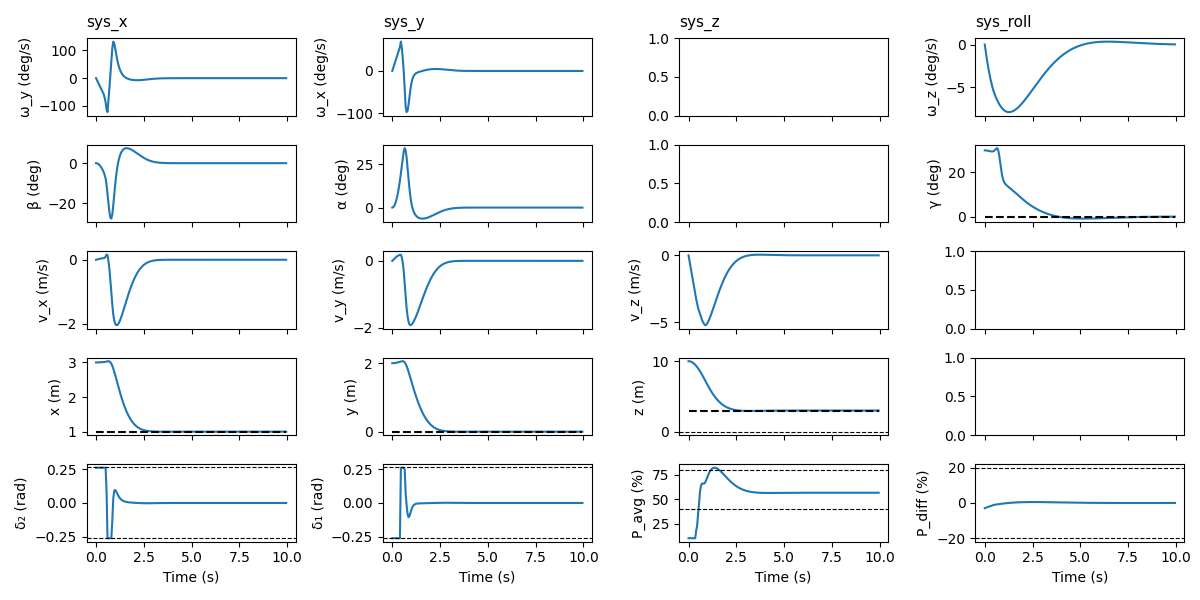

In [5]:
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol)
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs)

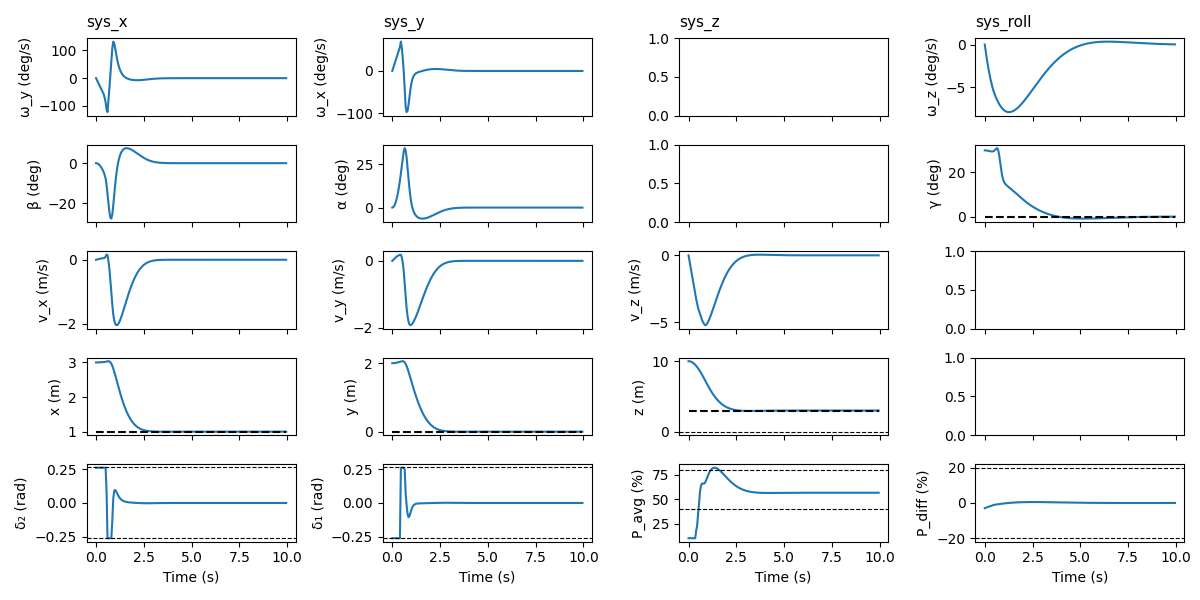

In [6]:
from src.vel_rocket_vis import plot_static_states_inputs
import matplotlib.pyplot as plt

# hack to intercept the figure
old_show = plt.show
def new_show():
    plt.savefig('../report/figures/del7_1_sim.png')
    old_show()

plt.show = new_show
# vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol)
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs)
plt.show = old_show

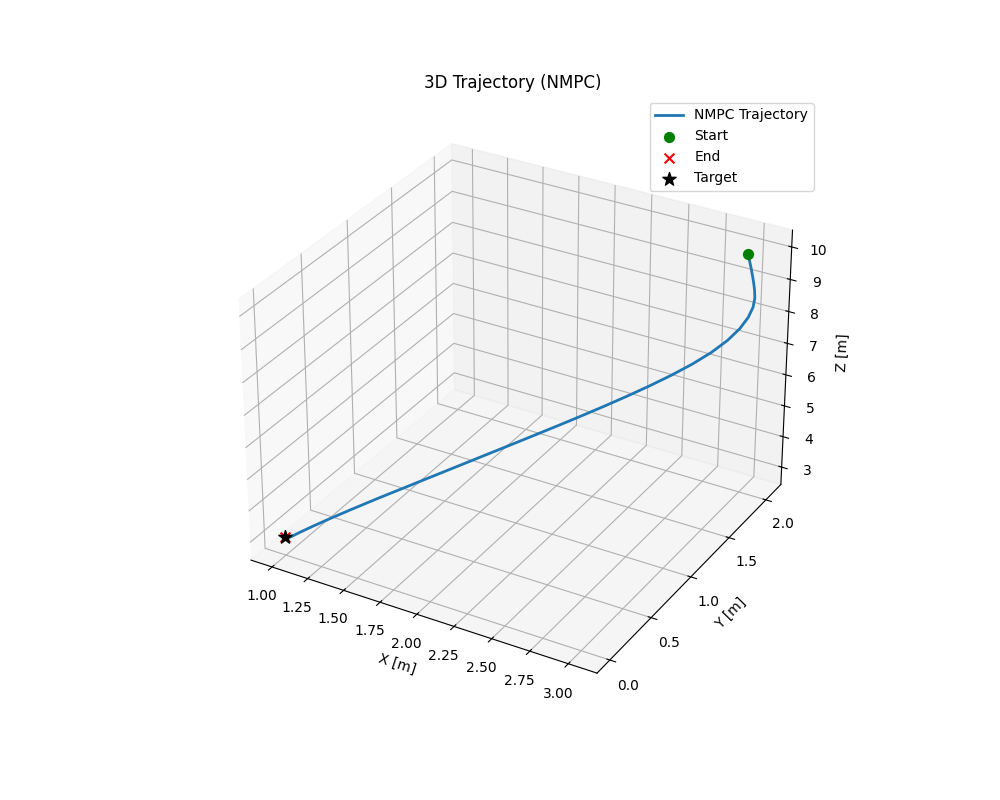

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract position data
x = x_cl[9, :-1]
y = x_cl[10, :-1]
z = x_cl[11, :-1]

# Plot trajectory
ax.plot(x, y, z, label='NMPC Trajectory', linewidth=2)
ax.scatter(x0[9], x0[10], x0[11], color='green', marker='o', s=50, label='Start') # Use x0 for start
ax.scatter(x[-1], y[-1], z[-1], color='red', marker='x', s=50, label='End')
ax.scatter(x_ref[9], x_ref[10], x_ref[11], color='black', marker='*', s=100, label='Target')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
ax.set_title('3D Trajectory (NMPC)')
ax.legend()
ax.grid(True)

plt.savefig('del7_1_trajectory.png')
plt.show()